In [1]:
! pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.4 MB/s eta 0:00:00


In [2]:
# Import necessary libraries
import pandas as pd
from chembl_webresource_client.new_client import new_client

In [3]:
# Target search for EGFR
target = new_client.target
target_query = target.search('EGFR')
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Mus musculus,Epidermal growth factor receptor erbB1,16.0,False,CHEMBL3608,"[{'accession': 'Q01279', 'component_descriptio...",SINGLE PROTEIN,10090
1,[],Homo sapiens,EGFR/PPP1CA,16.0,False,CHEMBL4523747,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
2,[],Homo sapiens,VHL/EGFR,16.0,False,CHEMBL4523998,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
3,[],Homo sapiens,CCN2-EGFR,16.0,False,CHEMBL5465557,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
4,[],Homo sapiens,Epidermal growth factor receptor erbB1,12.0,False,CHEMBL203,"[{'accession': 'P00533', 'component_descriptio...",SINGLE PROTEIN,9606
5,[],Homo sapiens,Protein cereblon/Epidermal growth factor receptor,12.0,False,CHEMBL4523680,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
6,[],Homo sapiens,Epidermal growth factor receptor,11.0,False,CHEMBL2363049,"[{'accession': 'P04626', 'component_descriptio...",PROTEIN FAMILY,9606
7,[],Homo sapiens,Epidermal growth factor receptor and ErbB2 (HE...,10.0,False,CHEMBL2111431,"[{'accession': 'P04626', 'component_descriptio...",PROTEIN FAMILY,9606
8,[],Homo sapiens,MER intracellular domain/EGFR extracellular do...,10.0,False,CHEMBL3137284,"[{'accession': 'P00533', 'component_descriptio...",CHIMERIC PROTEIN,9606
9,[],Homo sapiens,ErbB-2/ErbB-3 heterodimer,10.0,False,CHEMBL4630723,"[{'accession': 'P04626', 'component_descriptio...",PROTEIN COMPLEX,9606


In [4]:
selected_target = targets.target_chembl_id[4]
selected_target

'CHEMBL203'

In [5]:
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

In [7]:
df = pd.DataFrame.from_dict(res)

In [8]:
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,32260,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.041
1,None,None,32263,[],CHEMBL621151,Inhibition of autophosphorylation of human epi...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.3
2,None,None,32265,[],CHEMBL615325,Inhibition of ligand-induced proliferation in ...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,7.82
3,None,None,32267,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.17
4,None,None,32270,[],CHEMBL621151,Inhibition of autophosphorylation of human epi...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.04


In [9]:
df.shape

(18105, 46)

In [10]:
df2 = df[df.standard_value.notna()]
df2 = df2[df.canonical_smiles.notna()]
df2

<ipython-input-10-3852201246>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[df.canonical_smiles.notna()]


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,32260,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.041
1,None,None,32263,[],CHEMBL621151,Inhibition of autophosphorylation of human epi...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.3
2,None,None,32265,[],CHEMBL615325,Inhibition of ligand-induced proliferation in ...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,7.82
3,None,None,32267,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.17
4,None,None,32270,[],CHEMBL621151,Inhibition of autophosphorylation of human epi...,F,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18100,None,None,25785193,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL5471956,Selectivity interaction (TR-FRET binding assay...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,10.0
18101,None,None,25785838,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL5472624,Selectivity interaction (Kinase panel (radiome...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,nM,UO_0000065,None,50000.0
18102,None,None,25786818,"[{'comments': None, 'relation': None, 'result_...",CHEMBL5473647,Selectivity interaction (Kinase panel (Enzymat...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,10.0
18103,None,None,25787599,"[{'comments': None, 'relation': None, 'result_...",CHEMBL5474412,Selectivity interaction (Kinase panel (33PanQi...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,10.0


In [11]:
len(df2.canonical_smiles.unique())

10074

In [12]:
df2_nr = df2.drop_duplicates(['canonical_smiles'])
df2_nr

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,32260,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.041
3,None,None,32267,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,0.17
6,None,None,32680,[],CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,9.3
7,None,None,32770,[],CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,500.0
8,None,None,32772,[],CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,3000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18099,None,None,25783230,"[{'comments': None, 'relation': None, 'result_...",CHEMBL5468231,Selectivity interaction (Kinase panel (Invitro...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,20.0
18100,None,None,25785193,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL5471956,Selectivity interaction (TR-FRET binding assay...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,10.0
18102,None,None,25786818,"[{'comments': None, 'relation': None, 'result_...",CHEMBL5473647,Selectivity interaction (Kinase panel (Enzymat...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,10.0
18103,None,None,25787599,"[{'comments': None, 'relation': None, 'result_...",CHEMBL5474412,Selectivity interaction (Kinase panel (33PanQi...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor erbB1,9606,None,None,IC50,uM,UO_0000065,None,10.0


In [13]:
selection = ['molecule_chembl_id','canonical_smiles','standard_value']
df3 = df2_nr[selection]
df3

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0
6,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,9300.0
7,CHEMBL306988,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,500000.0
8,CHEMBL66879,O=C(O)/C=C/c1ccc(O)cc1,3000000.0
...,...,...,...
18099,CHEMBL4778541,CC(C)(C)c1ccc(C(=O)Nc2cn3cc(-n4ccnc4)ccc3n2)cc...,20000.0
18100,CHEMBL3622821,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...,10000.0
18102,CHEMBL1852688,CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC)cc(O...,10000.0
18103,CHEMBL3643413,CCC(=O)N1CC[C@H](Nc2ncnc3c2CN(c2cnc(OC)c(C(F)(...,10000.0


**Labeling compounds as either being active, inactive or intermediate The bioactivity data is in the IC50 unit. Compounds having values of less than 1000 nM will be considered to be active while those greater than 10,000 nM will be considered to be inactive. As for those values in between 1,000 and 10,000 nM will be referred to as intermediate.**

In [14]:
bioactivity_threshold = []
for i in df3.standard_value:
  if float(i) >= 10000:
    bioactivity_threshold.append("inactive")
  elif float(i) <= 1000:
    bioactivity_threshold.append("active")
  else:
    bioactivity_threshold.append("intermediate")

In [15]:
bioactivity_class = pd.Series(bioactivity_threshold, name='class')
df4 = pd.concat([df3, bioactivity_class], axis=1)
df4

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0,active
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0,inactive
6,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,9300.0,intermediate
7,CHEMBL306988,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,500000.0,inactive
8,CHEMBL66879,O=C(O)/C=C/c1ccc(O)cc1,3000000.0,active
...,...,...,...,...
10069,NaN,NaN,NaN,inactive
10070,NaN,NaN,NaN,inactive
10071,NaN,NaN,NaN,inactive
10072,NaN,NaN,NaN,inactive


Part-2:Exploratory Data Analysis

In [16]:
#Install conda and rdkit

! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

--2025-06-18 17:40:10--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’

Miniconda3-py37_4.8 100%[===================>]  81.12M   149MB/s    in 0.5s    

2025-06-18 17:40:11 (149 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - asn1crypto==1.3.0=py37_0
    - ca-certificates==2020.1.1=0
    - certifi==2019.11.28=py37_0
    - cffi==1.14.0=py37h2e261b9_0
    - chardet==3.0.4=py37_1003
    - conda-package-handling==1.

In [17]:
df4.head()

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(column, errors="raise")


,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0,active
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0,inactive
6,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,9300.0,intermediate
7,CHEMBL306988,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,500000.0,inactive
8,CHEMBL66879,O=C(O)/C=C/c1ccc(O)cc1,3000000.0,active


In [18]:
df_no_smiles = df4.drop(columns='canonical_smiles')

smiles = []
for i in df.canonical_smiles.tolist():
    cpd = str(i).split('.')
    cpd_longest = max(cpd, key=len)
    smiles.append(cpd_longest)

smiles = pd.Series(smiles, name='canonical_smiles', index=df.index)  # Keep index aligned with df

df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)
df_clean_smiles.head()

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL68920,41.0,active,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...
3,CHEMBL69960,170.0,inactive,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...
6,CHEMBL137635,9300.0,intermediate,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12
7,CHEMBL306988,500000.0,inactive,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1
8,CHEMBL66879,3000000.0,active,O=C(O)/C=C/c1ccc(O)cc1


In [19]:
# Ensure canonical_smiles column is string
df_clean_smiles['canonical_smiles'] = df_clean_smiles['canonical_smiles'].astype(str)

# Filter valid SMILES, keep original index for alignment
valid_smiles = df_clean_smiles[
    df_clean_smiles['canonical_smiles'].notna() &
    df_clean_smiles['canonical_smiles'].str.strip().ne('') &
    ~df_clean_smiles['canonical_smiles'].str.lower().isin(['nan', 'none'])
]

valid_smiles.head()

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL68920,41.0,active,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...
3,CHEMBL69960,170.0,inactive,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...
6,CHEMBL137635,9300.0,intermediate,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12
7,CHEMBL306988,500000.0,inactive,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1
8,CHEMBL66879,3000000.0,active,O=C(O)/C=C/c1ccc(O)cc1


Calculate Lipinski descriptors Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the druglikeness of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the Rule-of-Five or Lipinski's Rule.

The Lipinski's Rule stated the following:

Molecular weight < 500 Dalton Octanol-water partition coefficient (LogP) < 5 Hydrogen bond donors < 5 Hydrogen bond acceptors < 10

In [20]:
# Run this cell first in Colab
!pip install rdkit-pypi

     |████████████████████████████████| 29.2 MB 1.3 MB/s 


In [22]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
import numpy as np
import pandas as pd

In [23]:
#Calculate descriptors

# 1. Define lipinski function (your code snippet)
def lipinski(smiles, verbose=False):
    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData, columns=columnNames)

    return descriptors



In [24]:
df_lipinski = lipinski(valid_smiles['canonical_smiles'])
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,383.814,4.45034,3.0,4.0
1,482.903,3.61432,3.0,6.0
2,369.432,4.77200,1.0,6.0
3,283.287,2.31056,2.0,4.0
4,164.160,1.49000,2.0,2.0


In [25]:
# Reset indices before concatenation to avoid misalignment
valid_smiles = valid_smiles.reset_index(drop=True)
df_lipinski = df_lipinski.reset_index(drop=True)

# Combine original data with descriptors side-by-side
df_combined = pd.concat([valid_smiles, df_lipinski], axis=1)

# Check the combined dataframe
df_combined.head()

,molecule_chembl_id,standard_value,class,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL68920,41.0,active,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0
1,CHEMBL69960,170.0,inactive,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0
2,CHEMBL137635,9300.0,intermediate,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,369.432,4.77200,1.0,6.0
3,CHEMBL306988,500000.0,inactive,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,283.287,2.31056,2.0,4.0
4,CHEMBL66879,3000000.0,active,O=C(O)/C=C/c1ccc(O)cc1,164.160,1.49000,2.0,2.0


In [26]:
# Summary statistics for Lipinski descriptors
df_combined[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']].describe()

,MW,LogP,NumHDonors,NumHAcceptors
count,18072.000000,18072.000000,18072.000000,18072.000000
mean,455.576431,4.334665,2.014830,6.669987
std,120.495530,1.524347,1.176571,2.328695
min,32.046000,-17.132900,0.000000,0.000000
25%,377.450250,3.512200,1.000000,5.000000
50%,457.486000,4.355760,2.000000,7.000000
75%,527.558500,5.190320,3.000000,8.000000
max,1767.464000,13.116500,25.000000,46.000000


In [27]:
# Define rule violations
df_combined['violations'] = (
    (df_combined['MW'] > 500).astype(int) +
    (df_combined['LogP'] > 5).astype(int) +
    (df_combined['NumHDonors'] > 5).astype(int) +
    (df_combined['NumHAcceptors'] > 10).astype(int)
)

# Count how many compounds have 0, 1, 2, ... violations
df_combined['violations'].value_counts().sort_index()

,count
violations,
0,9913
1,4406
2,3374
3,376
4,3


In [28]:
def list_violations(row):
    violations = []
    if row['MW'] > 500:
        violations.append('MW>500')
    if row['LogP'] > 5:
        violations.append('LogP>5')
    if row['NumHDonors'] > 5:
        violations.append('HDonors>5')
    if row['NumHAcceptors'] > 10:
        violations.append('HAcceptors>10')

    if not violations:
        return 'None'  # no violations
    else:
        return ', '.join(violations)

df_combined['violation_details'] = df_combined.apply(list_violations, axis=1)
df_combined[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'violations', 'violation_details']].head()

,MW,LogP,NumHDonors,NumHAcceptors,violations,violation_details
0,383.814,4.45034,3.0,4.0,0,None
1,482.903,3.61432,3.0,6.0,0,None
2,369.432,4.77200,1.0,6.0,0,None
3,283.287,2.31056,2.0,4.0,0,None
4,164.160,1.49000,2.0,2.0,0,None


Convert IC50 to pIC50 To allow IC50 data to be more uniformly distributed, we will convert IC50 to the negative logarithmic scale which is essentially -log10(IC50).

This custom function pIC50() will accept a DataFrame as input and will:

Take the IC50 values from the standard_value column and converts it from nM to M by multiplying the value by 10 Take the molar value and apply -log10 Delete the standard_value column and create a new pIC50 column

In [29]:
import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', 1)

    return x


In [30]:
df_combined.standard_value.describe()

,standard_value
count,10074
unique,2849
top,10000.0
freq,579


In [31]:

-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [32]:

-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [33]:
np.float64(-1.0)

np.float64(-1.0)

In [34]:
def norm_value(df):
    # Convert to numeric and coerce errors to NaN
    df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')

    # Cap the values at 100,000,000
    df['standard_value_norm'] = df['standard_value'].apply(lambda x: min(x, 100000000) if pd.notnull(x) else x)

    # Drop the original column
    df = df.drop(columns=['standard_value'])

    return df

In [35]:
df_norm = norm_value(df_combined)
df_norm.head()

,molecule_chembl_id,class,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,violations,violation_details,standard_value_norm
0,CHEMBL68920,active,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,0,None,41.0
1,CHEMBL69960,inactive,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,0,None,170.0
2,CHEMBL137635,intermediate,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,369.432,4.77200,1.0,6.0,0,None,9300.0
3,CHEMBL306988,inactive,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,283.287,2.31056,2.0,4.0,0,None,500000.0
4,CHEMBL66879,active,O=C(O)/C=C/c1ccc(O)cc1,164.160,1.49000,2.0,2.0,0,None,3000000.0


In [36]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,1.007400e+04
mean,2.778615e+04
std,6.426266e+05
min,5.012000e-09
25%,2.722500e+01
50%,2.678000e+02
75%,5.300000e+03
max,5.500000e+07


In [37]:
def pIC50(df):
    pIC50_values = []

    for val in df['standard_value_norm']:
        try:
            molar = val * (10**-9)  # Convert nM to Molar
            if molar > 0:
                pIC50_val = -np.log10(molar)
            else:
                pIC50_val = np.nan
        except:
            pIC50_val = np.nan
        pIC50_values.append(pIC50_val)

    df['pIC50'] = pIC50_values
    df = df.drop('standard_value_norm', axis=1)

    return df


In [38]:
df_final = pIC50(df_norm)
df_final.head()

,molecule_chembl_id,class,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,violations,violation_details,pIC50
0,CHEMBL68920,active,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,0,None,7.387216
1,CHEMBL69960,inactive,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,0,None,6.769551
2,CHEMBL137635,intermediate,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,369.432,4.77200,1.0,6.0,0,None,5.031517
3,CHEMBL306988,inactive,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,283.287,2.31056,2.0,4.0,0,None,3.301030
4,CHEMBL66879,active,O=C(O)/C=C/c1ccc(O)cc1,164.160,1.49000,2.0,2.0,0,None,2.522879


In [39]:

df_final.shape

(18072, 10)

In [40]:

df_final.pIC50.describe()

,pIC50
count,10074.000000
mean,6.513382
std,1.488669
min,1.259637
25%,5.275724
50%,6.572190
75%,7.565033
max,17.299989


In [41]:
print(df_final.columns.tolist())

['molecule_chembl_id', 'class', 'canonical_smiles', 'MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'violations', 'violation_details', 'pIC50']


In [42]:

df_2class = df_final[df_final['class'] != 'intermediate']
df_2class.head(2)

,molecule_chembl_id,class,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,violations,violation_details,pIC50
0,CHEMBL68920,active,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,0,None,7.387216
1,CHEMBL69960,inactive,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,0,None,6.769551


**Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

In [43]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

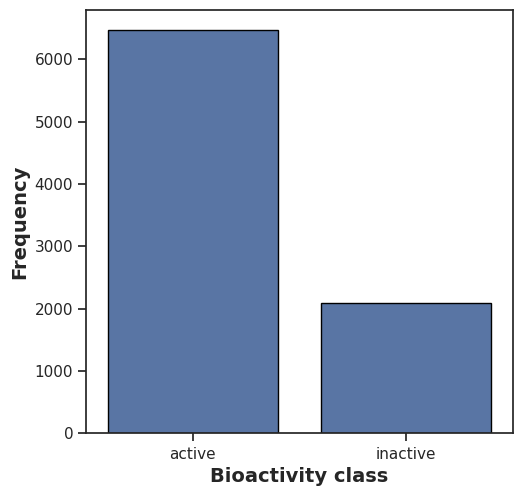

In [44]:

plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

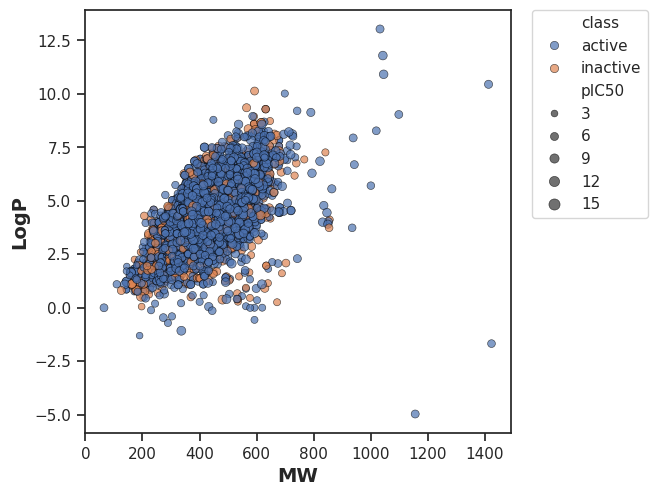

In [45]:

#Scatter plot of MW versus LogP
#It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

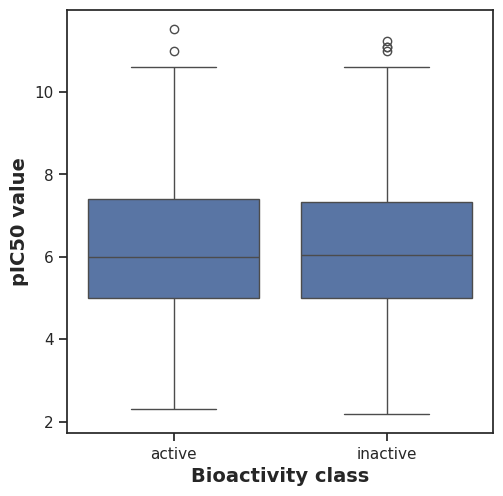

In [46]:

#Box plots
#pIC50 value

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

In [47]:
#Statistical analysis | Mann-Whitney U Test
 # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/

import pandas as pd
from scipy.stats import mannwhitneyu

def mannwhitney(descriptor, verbose=False):
    # Select relevant columns
    selection = [descriptor, 'class']
    df = df_2class[selection]

    # Split into active and inactive groups
    active = df[df['class'] == 'active'][descriptor]
    inactive = df[df['class'] == 'inactive'][descriptor]

    # Perform Mann-Whitney U test
    stat, p = mannwhitneyu(active, inactive)

    # Interpret result
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    # Create results DataFrame
    results = pd.DataFrame({
        'Descriptor': [descriptor],
        'Statistics': [stat],
        'p': [p],
        'alpha': [alpha],
        'Interpretation': [interpretation]
    })

    # Save result
    filename = f'mannwhitneyu_{descriptor}.csv'
    results.to_csv(filename, index=False)

    if verbose:
        print(results)

    return results


In [48]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,NaN,NaN,0.05,Different distribution (reject H0)


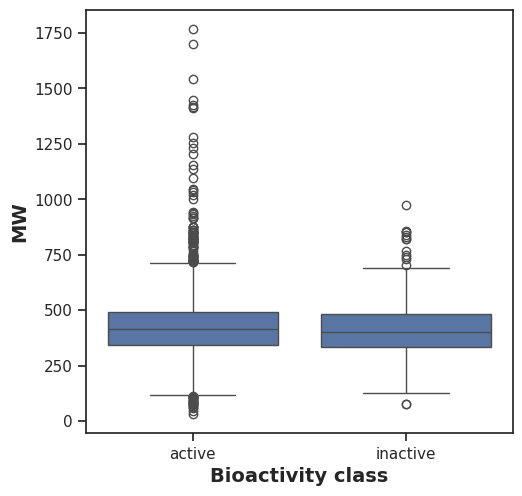

In [49]:

#MW

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [50]:

mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,7101592.0,0.000409,0.05,Different distribution (reject H0)


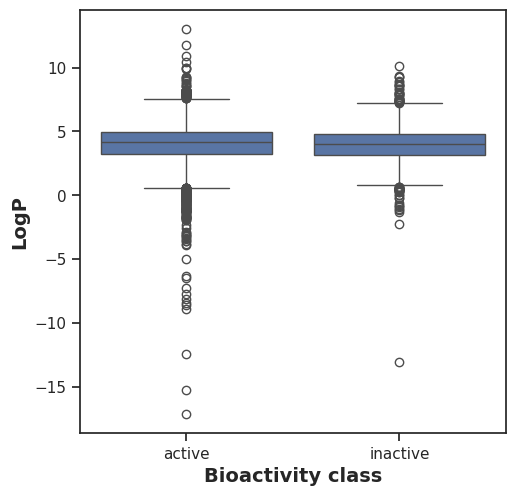

In [51]:
#LogP

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

In [52]:
#Statistical analysis | Mann-Whitney U Test

mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,7052298.0,0.00243,0.05,Different distribution (reject H0)


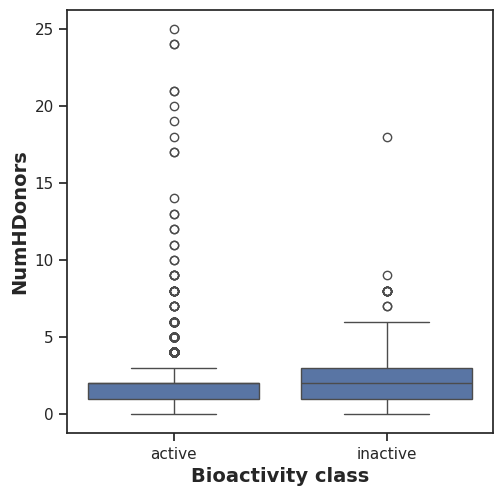

In [53]:
#NumHDonors

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

In [54]:
#Statistical analysis | Mann-Whitney U Test

mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,6548483.0,0.02658,0.05,Different distribution (reject H0)


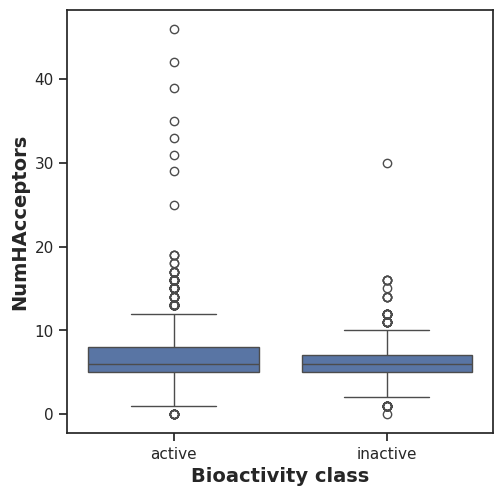

In [55]:
#NumHAcceptors

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [56]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,7058929.5,0.001741,0.05,Different distribution (reject H0)


**Interpretation of Statistical Results Box Plots pIC50 values Taking a look at pIC50 values, the actives and inactives displayed statistically significant difference, which is to be expected since threshold values (IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives, corresponding to pIC50 > 6 = Actives and pIC50 < 5 = Inactives) were used to define actives and inactives.

Lipinski's descriptors Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited no difference between the actives and inactives while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows statistically significant difference between actives and inactives.**

**Part-3:Descriptor Calculation and Dataset Preparation**

In [57]:
from google.colab import files

# Upload the .zip and .sh files
uploaded = files.upload()


Saving PaDEL-Descriptor.zip to PaDEL-Descriptor.zip


In [ ]:
from google.colab import files

# Upload the .zip and .sh files
uploaded = files.upload()

Saving padel.sh to padel.sh


In [58]:
!unzip PaDEL-Descriptor.zip -d PaDEL-Descriptor


Archive:  PaDEL-Descriptor.zip
  inflating: PaDEL-Descriptor/Descriptors.xls  
  inflating: PaDEL-Descriptor/descriptors.xml  
   creating: PaDEL-Descriptor/lib/
  inflating: PaDEL-Descriptor/lib/ambit2-base-2.4.7-SNAPSHOT.jar  
  inflating: PaDEL-Descriptor/lib/ambit2-core-2.4.7-SNAPSHOT.jar  
  inflating: PaDEL-Descriptor/lib/ambit2-smarts-2.4.7-SNAPSHOT.jar  
  inflating: PaDEL-Descriptor/lib/appframework-1.0.3.jar  
  inflating: PaDEL-Descriptor/lib/cdk-1.4.15.jar  
  inflating: PaDEL-Descriptor/lib/commons-cli-1.2.jar  
  inflating: PaDEL-Descriptor/lib/guava-17.0.jar  
  inflating: PaDEL-Descriptor/lib/jama.jar  
  inflating: PaDEL-Descriptor/lib/jgrapht-0.6.0.jar  
  inflating: PaDEL-Descriptor/lib/l2fprod-common-all.jar  
  inflating: PaDEL-Descriptor/lib/libPaDEL-Descriptor.jar  
  inflating: PaDEL-Descriptor/lib/libPaDEL-Jobs.jar  
  inflating: PaDEL-Descriptor/lib/libPaDEL.jar  
  inflating: PaDEL-Descriptor/lib/swing-worker-1.1.jar  
  inflating: PaDEL-Descriptor/lib/vecmat

In [59]:
!ls PaDEL-Descriptor



Descriptors.xls  descriptors.xml  lib  license	PaDEL-Descriptor.jar


In [60]:
!ls PaDEL-Descriptor/*.xml


PaDEL-Descriptor/descriptors.xml


In [61]:
script = """
java -Xms1G -Xmx1G -Djava.awt.headless=true -jar ./PaDEL-Descriptor/PaDEL-Descriptor.jar \\
-removesalt -standardizenitro -fingerprints \\
-dir ./ -file descriptors_output.csv
"""

with open("PaDEL-Descriptor/padel.sh", "w") as file:
    file.write(script)



In [62]:
!chmod +x PaDEL-Descriptor/padel.sh
!PaDEL-Descriptor/padel.sh


Descriptor calculation completed in 0.575 secs . Average speed: ∞ s/mol.


In [63]:
selection = ['canonical_smiles','molecule_chembl_id']
df3_selection = df_2class[selection]

In [64]:
df3_selection

,canonical_smiles,molecule_chembl_id
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960
3,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,CHEMBL306988
4,O=C(O)/C=C/c1ccc(O)cc1,CHEMBL66879
5,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-],CHEMBL77085
...,...,...
18067,COCC(=O)NC/C=C/c1ccc2ncnc(Nc3ccc(Oc4ccc(C)nc4)...,NaN
18068,CCc1cc(Nc2nccc(-c3c(-c4ccc(OC)c(C(=O)Nc5c(F)cc...,NaN
18069,CCc1cc(Nc2nccc(-c3c(-c4ccc(OC)c(C(=O)Nc5c(F)cc...,NaN
18070,O[C@H]1CC[C@H](Nc2ncc3nc(Nc4c(F)cc(F)cc4F)n([C...,NaN


In [65]:
df_combined

,molecule_chembl_id,standard_value,class,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,violations,violation_details,standard_value_norm
0,CHEMBL68920,41.0,active,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,0,None,41.0
1,CHEMBL69960,170.0,inactive,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,0,None,170.0
2,CHEMBL137635,9300.0,intermediate,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,369.432,4.77200,1.0,6.0,0,None,9300.0
3,CHEMBL306988,500000.0,inactive,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,283.287,2.31056,2.0,4.0,0,None,500000.0
4,CHEMBL66879,3000000.0,active,O=C(O)/C=C/c1ccc(O)cc1,164.160,1.49000,2.0,2.0,0,None,3000000.0
...,...,...,...,...,...,...,...,...,...,...,...
18067,NaN,NaN,NaN,COCC(=O)NC/C=C/c1ccc2ncnc(Nc3ccc(Oc4ccc(C)nc4)...,469.545,4.95334,2.0,7.0,0,None,NaN
18068,NaN,NaN,NaN,CCc1cc(Nc2nccc(-c3c(-c4ccc(OC)c(C(=O)Nc5c(F)cc...,851.981,6.85800,2.0,12.0,3,"MW>500, LogP>5, HAcceptors>10",NaN
18069,NaN,NaN,NaN,CCc1cc(Nc2nccc(-c3c(-c4ccc(OC)c(C(=O)Nc5c(F)cc...,851.981,6.85800,2.0,12.0,3,"MW>500, LogP>5, HAcceptors>10",NaN
18070,NaN,NaN,NaN,O[C@H]1CC[C@H](Nc2ncc3nc(Nc4c(F)cc(F)cc4F)n([C...,448.449,3.66400,3.0,8.0,0,None,NaN


In [66]:
# Create a .smi file from df_combind for PaDEL
df_combined[["canonical_smiles", "molecule_chembl_id"]].to_csv("molecule.smi", sep="\t", index=False, header=False)

In [67]:

! cat molecule.smi | head -5

Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1	CHEMBL68920
Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21	CHEMBL69960
CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12	CHEMBL137635
CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1	CHEMBL306988
O=C(O)/C=C/c1ccc(O)cc1	CHEMBL66879


In [68]:
! cat molecule.smi | wc -l

18072


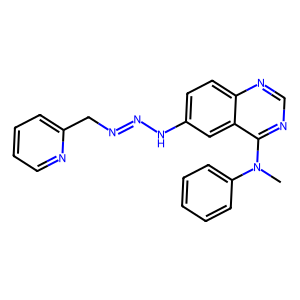

In [69]:

from rdkit import Chem
from rdkit.Chem import Draw

# Example SMILES (replace with your compound)
smiles = "CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12"  #

# Convert SMILES to molecule
mol = Chem.MolFromSmiles(smiles)

# Display molecule structure
Draw.MolToImage(mol)

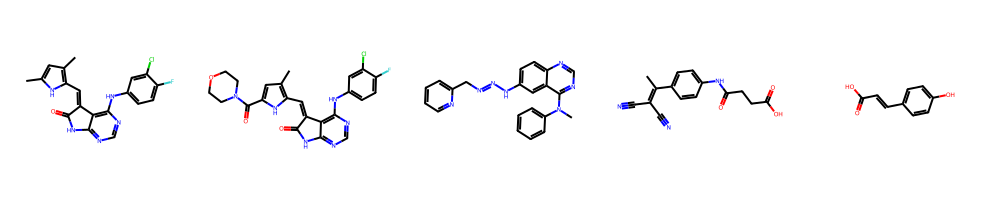

In [70]:
# List of SMILES strings (replace with your own 5 molecules)
smiles_list = [
    "Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1",   #CHEMBL68920
    "Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21",  #CHEMBL69960
    "CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12",  # CHEMBL137635
    "CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1",  #CHEMBL306988
    "O=C(O)/C=C/c1ccc(O)cc1"  # CHEMBL66879
]

# Convert each SMILES to an RDKit molecule object
mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]

# Draw them in a 1x5 grid (you can adjust molsPerRow)
img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200))
img

In [71]:
%%writefile padel.sh
java -Xms1G -Xmx1G -Djava.awt.headless=true \
-jar ./PaDEL-Descriptor/PaDEL-Descriptor.jar \
-removesalt -standardizenitro -fingerprints \
-descriptortypes ./PaDEL-Descriptor/descriptors.xml \
-dir ./ -file descriptors_output.csv


Writing padel.sh


In [72]:
!chmod +x padel.sh
!./padel.sh


Streaming output truncated to the last 5000 lines.
Processing AUTOGEN_molecule_13074 in molecule.smi (13074/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13075 in molecule.smi (13075/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13076 in molecule.smi (13076/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13077 in molecule.smi (13077/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13078 in molecule.smi (13078/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13079 in molecule.smi (13079/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13080 in molecule.smi (13080/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13082 in molecule.smi (13082/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13081 in molecule.smi (13081/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_13083 in molecule.smi (13083/18072). Average speed: 0.32 s/mol.
Processing AUTOGEN_molecule_1

In [73]:
! ls -l

total 136176
-rw-r--r-- 1 root root 32210325 Jun 18 19:28 descriptors_output.csv
-rw-r--r-- 1 root root      122 Jun 18 17:45 mannwhitneyu_LogP.csv
-rw-r--r-- 1 root root      121 Jun 18 17:45 mannwhitneyu_MW.csv
-rw-r--r-- 1 root root      131 Jun 18 17:46 mannwhitneyu_NumHAcceptors.csv
-rw-r--r-- 1 root root      125 Jun 18 17:45 mannwhitneyu_NumHDonors.csv
-rw-r--r-- 1 root root       93 Jun 18 17:45 mannwhitneyu_pIC50.csv
-rwxr-xr-x 1 root root 85055499 Feb 13 19:49 Miniconda3-py37_4.8.2-Linux-x86_64.sh
-rw-r--r-- 1 root root  1160163 Jun 18 17:51 molecule.smi
drwxr-xr-x 4 root root     4096 Jun 18 17:51 PaDEL-Descriptor
-rw-r--r-- 1 root root 20875190 Jun 18 17:48 PaDEL-Descriptor.zip
-rwxr-xr-x 1 root root      230 Jun 18 17:51 padel.sh
-rw-r--r-- 1 root root    14366 Jun 18 17:44 plot_bioactivity_class.pdf
-rw-r--r-- 1 root root    15338 Jun 18 17:45 plot_ic50.pdf
-rw-r--r-- 1 root root    15807 Jun 18 17:45 plot_LogP.pdf
-rw-r--r-- 1 root root    14011 Jun 18 17:45 plot_MW.pdf


In [74]:
df_X = pd.read_csv('descriptors_output.csv')

In [75]:
df_X

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL68920,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CHEMBL69960,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CHEMBL306988,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CHEMBL66879,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CHEMBL137635,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18067,AUTOGEN_molecule_18068,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18068,AUTOGEN_molecule_18069,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18069,AUTOGEN_molecule_18070,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18070,AUTOGEN_molecule_18071,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
df_X = df_X.drop(columns=['Name'])
df_X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18067,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18068,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18069,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18070,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Y variable Convert IC50 to pIC50

In [77]:
df_Y = df_2class['pIC50']
df_Y


,pIC50
0,7.387216
1,6.769551
3,3.301030
4,2.522879
5,4.017729
...,...
18067,NaN
18068,NaN
18069,NaN
18070,NaN


In [78]:
dataset = pd.concat([df_X,df_Y], axis=1)
dataset

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.387216
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.769551
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.301030
4,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.522879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18067,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
18068,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
18069,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
18070,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


Part-4:Regression Models with Random Forest

In [79]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold

In [80]:
df=dataset

In [82]:
# Define features and target
X = df.drop('pIC50', axis=1)
Y = df['pIC50']

In [83]:
# Remove low variance features
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_reduced = selection.fit_transform(X)

In [84]:
# Convert reduced X back to DataFrame to keep compatibility
X_df = pd.DataFrame(X_reduced)

In [85]:
# Convert Y to Series with a name
Y_series = pd.Series(Y.values, name="pIC50")

In [86]:
# Combine X and Y for dropping NaNs
data = pd.concat([X_df, Y_series], axis=1)

In [87]:
# Drop rows with any NaNs
data_clean = data.dropna()

In [88]:

# Separate cleaned data
X_clean = data_clean.drop(columns=["pIC50"])
Y_clean = data_clean["pIC50"]

In [89]:
# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X_clean, Y_clean, test_size=0.2)

In [90]:
# Train the model
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)


RandomForestRegressor()

In [91]:
# Evaluate the model
r = model.score(X_test, Y_test)
print("R² score:", r)

R² score: 0.44621566493656895


In [92]:
r = model.score(X_test, Y_test)
r

0.44621566493656895

In [93]:
Y_pred = model.predict(X_test)

Scatter Plot of Experimental vs Predicted pIC50 Values

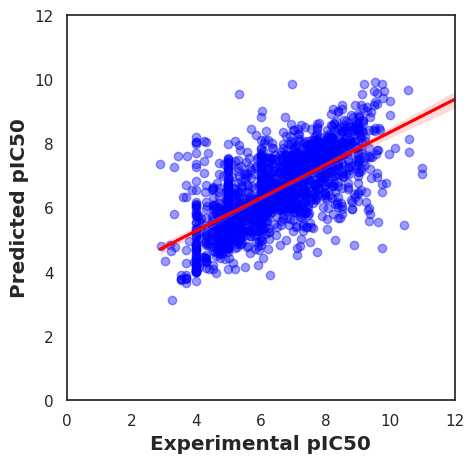

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)
sns.set_style("white")

# Ensure Y_test and Y_pred are aligned Series/arrays
ax = sns.regplot(
    x=Y_test,
    y=Y_pred,
    scatter_kws={'alpha': 0.4, 'color': 'blue'},    # scatter points blue
    line_kws={'color': 'red'}                        # regression line red
)

ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show()


**Part-5:Comparing Regressors**

In [95]:
dataset.head()

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.387216
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.769551
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.301030
4,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.522879


In [98]:
import sys
print(sys.version)


3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [99]:
# Step 1: Upgrade pip, setuptools, wheel to ensure smooth builds
!pip install --upgrade pip setuptools wheel

     |████████████████████████████████| 2.1 MB 4.6 MB/s 
     |████████████████████████████████| 804 kB 38.9 MB/s 
     |████████████████████████████████| 65 kB 4.3 MB/s 
  Attempting uninstall: pip
    Found existing installation: pip 20.0.2
    Uninstalling pip-20.0.2:
      Successfully uninstalled pip-20.0.2
  Attempting uninstall: setuptools
    Found existing installation: setuptools 45.2.0.post20200210
    Uninstalling setuptools-45.2.0.post20200210:
      Successfully uninstalled setuptools-45.2.0.post20200210
  Attempting uninstall: wheel
    Found existing installation: wheel 0.34.2
    Uninstalling wheel-0.34.2:
      Successfully uninstalled wheel-0.34.2


In [100]:
# Step 2: Install xgboost (compatible with LazyPredict)
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 2.3 MB/s eta 0:00:00


In [101]:
# Step 3: Install a stable version of lightgbm (v3.3.5 is a good choice)
!pip install lightgbm==3.3.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.4 MB/s eta 0:00:00


In [102]:
# Step 4: Install LazyPredict without automatic dependency resolution (avoids version conflicts)
!pip install lazypredict --no-deps

In [103]:
import lazypredict
print(lazypredict.__file__)

/usr/local/lib/python3.7/site-packages/lazypredict/__init__.py


In [104]:

file_path = "/usr/local/lib/python3.7/site-packages/lazypredict/Supervised.py"

with open(file_path, "r") as f:
    content = f.read()

content = content.replace("sparse=False", "sparse_output=False")

with open(file_path, "w") as f:
    f.write(content)

print("Patch applied successfully.")

Patch applied successfully.


In [105]:
import lazypredict
from lazypredict.Supervised import LazyRegressor
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
models_train,predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test,predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

 98%|█████████▊| 41/42 [04:09<00:04,  4.02s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003786 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 426
[LightGBM] [Info] Number of data points in the train set: 7308, number of used features: 142
[LightGBM] [Info] Start training from score 6.552699


100%|██████████| 42/42 [04:10<00:00,  5.96s/it]


'tuple' object has no attribute '__name__'
Invalid Regressor(s)


 98%|█████████▊| 41/42 [03:19<00:02,  2.45s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003616 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 426
[LightGBM] [Info] Number of data points in the train set: 7308, number of used features: 142
[LightGBM] [Info] Start training from score 6.552699


100%|██████████| 42/42 [03:20<00:00,  4.77s/it]


In [106]:
# Performance table of the training set (80% subset)
predictions_train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreeRegressor,0.94,0.94,0.36,0.42
DecisionTreeRegressor,0.94,0.94,0.36,0.29
ExtraTreesRegressor,0.94,0.94,0.36,23.29
GaussianProcessRegressor,0.94,0.94,0.36,76.04
RandomForestRegressor,0.89,0.89,0.49,17.10
BaggingRegressor,0.86,0.87,0.54,2.31
XGBRegressor,0.81,0.81,0.64,3.18
MLPRegressor,0.80,0.81,0.65,34.20
KNeighborsRegressor,0.64,0.64,0.88,0.98


In [107]:

# Performance table of the test set (20% subset)
predictions_test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
XGBRegressor,0.42,0.47,1.09,1.14
HistGradientBoostingRegressor,0.41,0.45,1.10,3.29
RandomForestRegressor,0.40,0.45,1.10,16.72
SVR,0.38,0.43,1.12,12.01
NuSVR,0.38,0.43,1.13,9.84
LGBMRegressor,0.37,0.42,1.13,0.70
BaggingRegressor,0.37,0.42,1.14,1.87
KNeighborsRegressor,0.33,0.39,1.17,0.30
MLPRegressor,0.27,0.33,1.22,30.80


[(0.0, 1.0)]

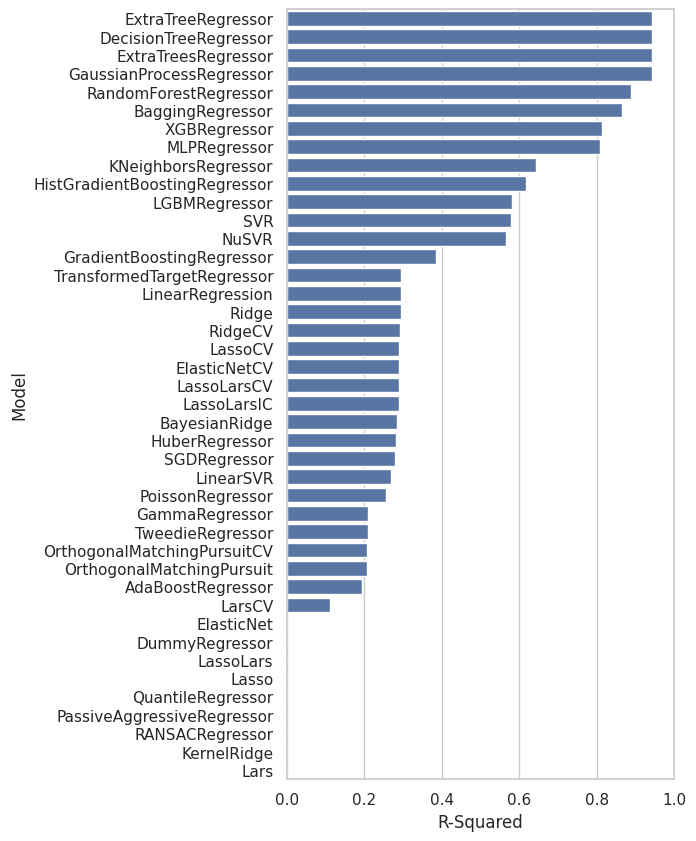

In [108]:
#Data visualization of model performance

# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="R-Squared", data=predictions_train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

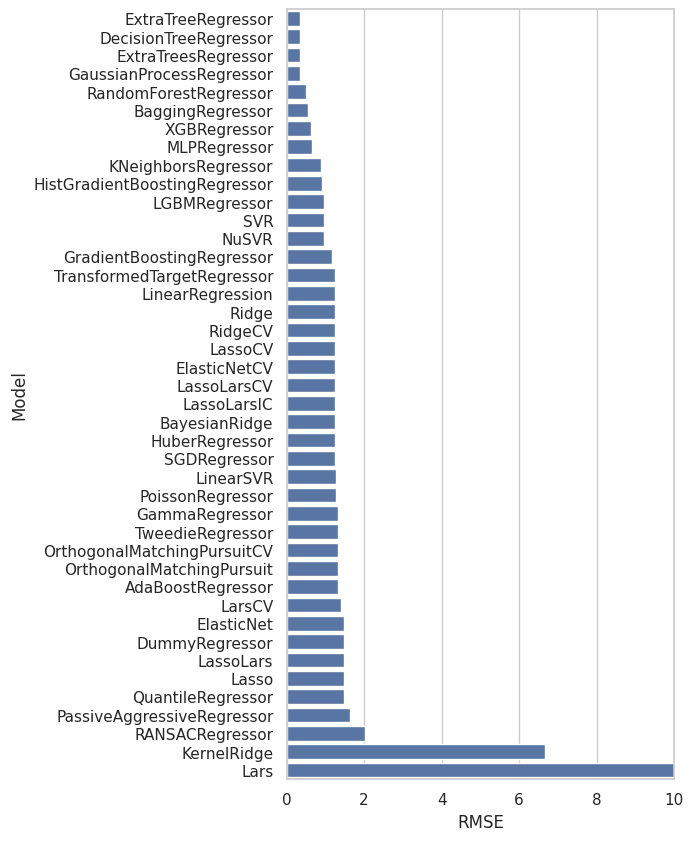

In [109]:
 #Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="RMSE", data=predictions_train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

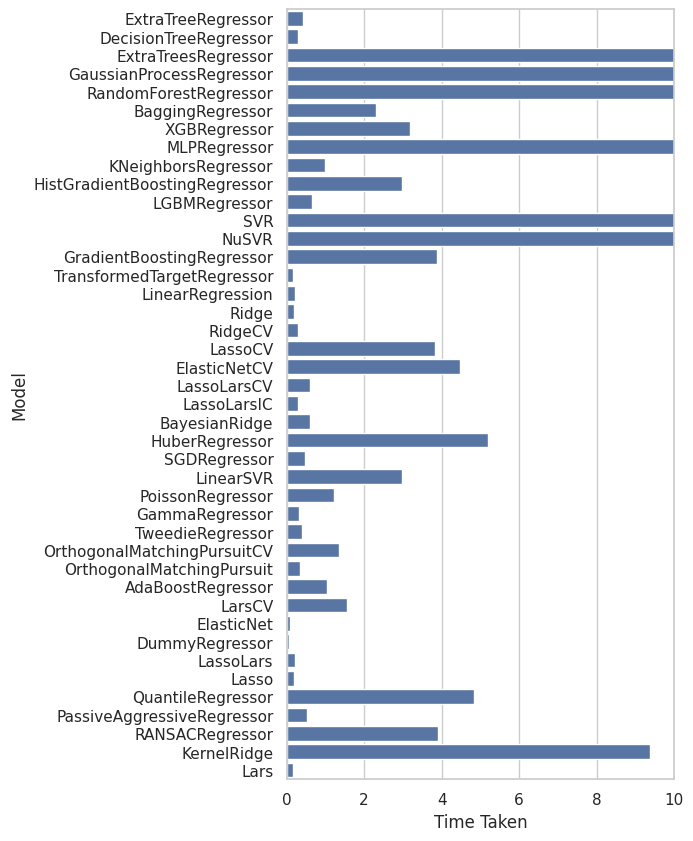

In [110]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="Time Taken", data=predictions_train)
ax.set(xlim=(0, 10))

In [111]:
#Done